In [1]:
# LOAD DỮ LIỆU TỪ FILE CSV

import pandas as pd

# Đường dẫn đến dữ liệu
path_iris = '../data/Gốc/iris.csv'
path_mall = '../data/Gốc/Mall_Customers.csv'

# Load dữ liệu
df_iris = pd.read_csv(path_iris)
df_mall = pd.read_csv(path_mall)

print("Đã load dữ liệu")

Đã load dữ liệu


In [2]:

# XỬ LÝ DỮ LIỆU THIẾU CỦA MALL_CUSTOMER VÀ IRIS


#=====================================================================
# XỬ LÍ MALL CUSTOMER
# Điền giá trị thiếu bằng giá trị trung bình (Mean) hoặc trung vị (Median) cho các đặc trưng là số trong khoảng giá trị
df_mall['Annual Income (k$)'] = df_mall['Annual Income (k$)'].fillna(df_mall['Annual Income (k$)'].median())
df_mall['Spending Score (1-100)'] = df_mall['Spending Score (1-100)'].fillna(df_mall['Spending Score (1-100)'].median())
df_mall['Age'] = df_mall['Age'].fillna(df_mall['Age'].mean())

# Điền giá trị xuất hiện nhiều nhất (Mode) đối với các đặc trưng phân loại
df_mall['Genre'] = df_mall['Genre'].fillna(df_mall['Genre'].mode()[0])

print("\nĐã hoàn tất kiểm tra và xử lý dữ liệu thiếu của Mall_Customer.")

#=====================================================================
# XỬ LÍ IRIS
df_iris['petal_length'] = df_iris['petal_length'].fillna(df_iris['petal_length'].mean())
df_iris['petal_width'] = df_iris['petal_width'].fillna(df_iris['petal_width'].mean())
df_iris['sepal_length'] = df_iris['sepal_length'].fillna(df_iris['sepal_length'].mean())
df_iris['sepal_width'] = df_iris['sepal_width'].fillna(df_iris['sepal_width'].mean())

df_iris['species'] = df_iris['species'].fillna(df_iris['species'].mode()[0])


print("Đã hoàn tất kiển tra và xử lý dữ liệu thiếu của Iris")


Đã hoàn tất kiểm tra và xử lý dữ liệu thiếu của Mall_Customer.
Đã hoàn tất kiển tra và xử lý dữ liệu thiếu của Iris


In [8]:
# CHUẨN HÓA DỮ LIỆU  (Z-SCORE NORMALIZATION)

def Z_score_normalization(df_column):
    # 1. Tính giá trị trung bình 
    mean_val = df_column.mean()
    
    # 2. Tính độ lệch chuẩn 
    std_val = df_column.std(ddof=0)
    
    # 3. Tránh trường hợp chia cho 0 
    if std_val == 0:
        return df_column - mean_val
        
    # 4. Áp dụng công thức Z-score
    scaled_column = (df_column - mean_val) / std_val
    return scaled_column


# 1. CHUẨN HÓA CHO DỮ LIỆU IRIS
df_iris_scaled = df_iris.copy()

# Xác định các cột cần chuẩn hóa (chỉ lấy các cột số)
cols_to_scale_iris = df_iris.select_dtypes(include=['float64', 'int64']).columns

# Tiến hành chuẩn hóa từng cột
for col in cols_to_scale_iris:
    df_iris_scaled[col] = Z_score_normalization(df_iris_scaled[col])

print("DỮ LIỆU IRIS SAU KHI CHUẨN HÓA THỦ CÔNG (5 dòng đầu)")
print(df_iris_scaled.head())

# Lưu bảng dữ liệu iris đã chuẩn hóa
df_iris_scaled.to_csv('../data/Đã xử lí/scaled_iris.csv', index=False)
print("Đã lưu lại bảng dữ liệu đã chuẩn hóa vào file 'scaled_iris.csv'\n")
print("==========================================================================")

#================================================================
# 2. CHUẨN HÓA CHO DỮ LIỆU MALL CUSTOMERS
df_mall_scaled = df_mall.copy()

# cột dạng chữ (Giới tính) cần được chuyển thành số
df_mall_scaled['Genre'] = df_mall_scaled['Genre'].map({'Male': 0, 'Female': 1})

# Xác định các đặc trưng cần chuẩn hóa cho thuật toán 
# Không chuẩn hóa CustomerID và Genre (đã chuẩn hóa trước đó)
cols_to_scale_mall = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Tiến hành chuẩn hóa từng cột
for col in cols_to_scale_mall:
    df_mall_scaled[col] = Z_score_normalization(df_mall_scaled[col])

# Bỏ cột CustomerID vì KNN dựa trên khoảng cách, đưa ID vào sẽ làm sai lệch mô hình
df_mall_scaled = df_mall_scaled.drop(columns=['CustomerID'])

print("\n DỮ LIỆU MALL CUSTOMERS SAU KHI CHUẨN HÓA THỦ CÔNG (5 dòng đầu)")
print(df_mall_scaled.head())

# Lưu bảng dữ liệu Mall_customer đã chuẩn hóa
df_mall_scaled.to_csv('../data/Đã xử lí/scaled_Mall_Customer.csv', index=False)
print("Đã lưu lại bảng dữ liệu đã chuẩn hóa vào file 'scaled_Mall_Customer.csv' ")


DỮ LIỆU IRIS SAU KHI CHUẨN HÓA THỦ CÔNG (5 dòng đầu)
   sepal_length  sepal_width  petal_length  petal_width species
0     -0.897434     1.063771     -1.359452    -1.326671  setosa
1     -1.142035    -0.120958     -1.359452    -1.326671  setosa
2     -1.386637     0.352933     -1.417167    -1.326671  setosa
3     -1.508937     0.115987     -1.301738    -1.326671  setosa
4     -1.019735     0.000000     -1.359452    -1.326671  setosa
Đã lưu lại bảng dữ liệu đã chuẩn hóa vào file 'scaled_iris.csv'


 DỮ LIỆU MALL CUSTOMERS SAU KHI CHUẨN HÓA THỦ CÔNG (5 dòng đầu)
   Genre       Age  Annual Income (k$)  Spending Score (1-100)
0      0 -1.424569           -1.738999               -0.434801
1      0 -1.281035           -1.738999                1.195704
2      1 -1.352802           -1.700830               -1.715913
3      1 -1.137502           -1.700830                1.040418
4      1 -0.563369           -1.662660               -0.395980
Đã lưu lại bảng dữ liệu đã chuẩn hóa vào file 'scaled_M

In [4]:
print("Thống kê dữ liệu Mall Customers:")
print(df_mall.describe())

print("\nThống kê dữ liệu Iris:")
print(df_iris.describe())

Thống kê dữ liệu Mall Customers:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

Thống kê dữ liệu Iris:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.833793     3.051049      3.755479     1.193103
std        0.820396     0.423451      1.738472     0.751076
min        4.300000     2.000000     

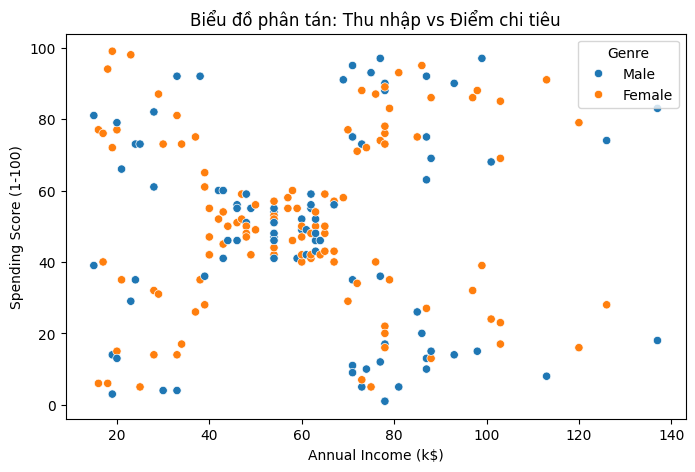

<Figure size 800x500 with 0 Axes>

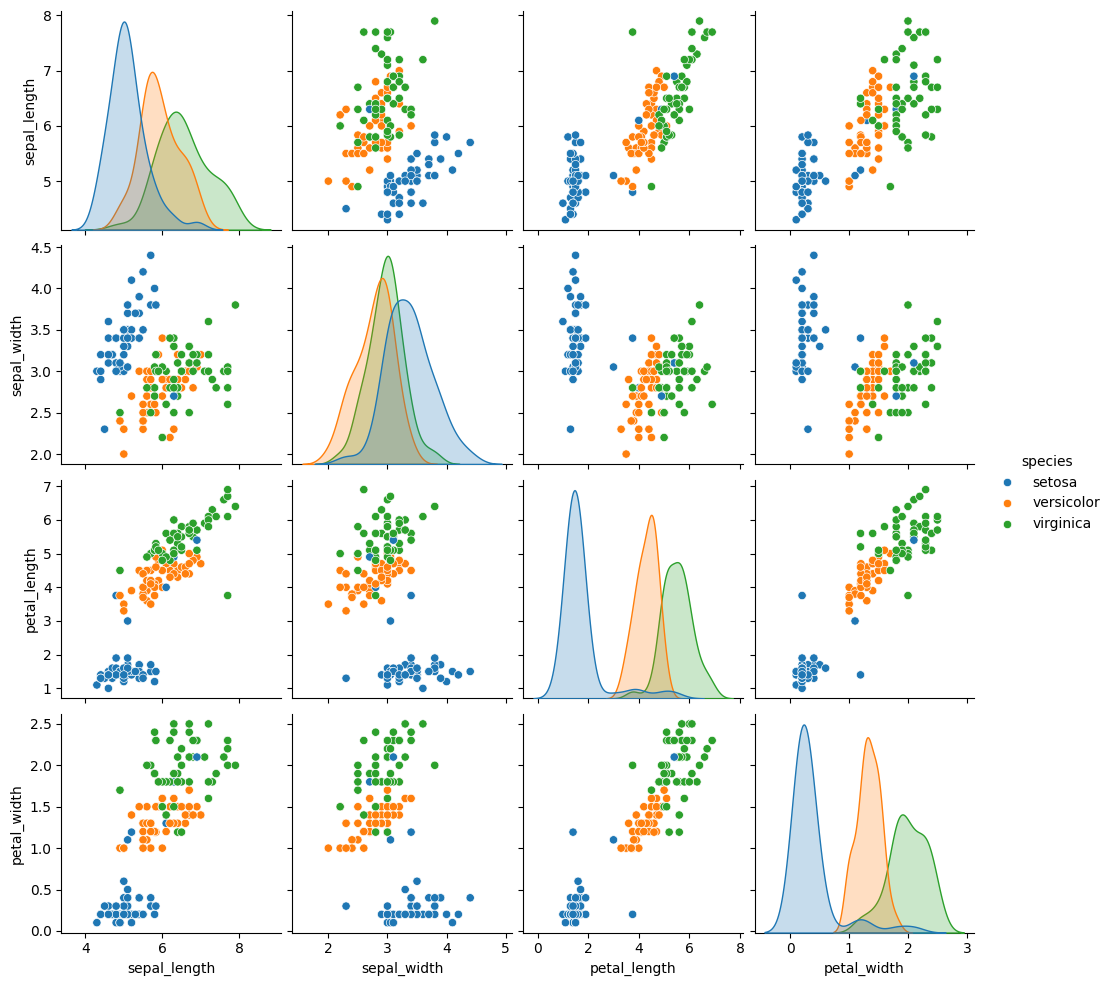

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ biểu đồ phân tán cho Mall Customers để thấy các nhóm khách hàng tiềm năng
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_mall, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre')
plt.title('Biểu đồ phân tán: Thu nhập vs Điểm chi tiêu')
plt.show()

# Vẽ biểu đồ phân phối các loài hoa trong bộ Iris
plt.figure(figsize=(8, 5))
sns.pairplot(df_iris, hue='species')
plt.show()